# Hypothesis Testing
## Relationship Between Two Variables

Before we tested a **single proportion** against a known value (e.g., is the unemployment rate different from 30%?).

This week we ask a different kind of question: **is there a relationship between two variables?**

- Is there a difference in callback rates between Black and White job applicants?
- Is there a difference in callback rates between men and women?

The core logic is the same — simulate a null distribution, then ask how extreme our observed result is.

## Hypotheses

**Null hypothesis ($H_0$):**
> There is **no relationship** between treatment and outcome — any observed difference is due to chance.

**Alternative hypothesis ($H_A$):**
> There **is** a relationship — the difference is not due to chance.

### Key insight: the permutation approach

Under $H_0$, the treatment variable (e.g., race) has **no impact** on the outcome (e.g., callback). That means if we randomly reshuffled the treatment labels, the outcome values wouldn't change — because they were never related to begin with.

This gives us a way to simulate the null distribution:
1. Shuffle the treatment variable randomly
2. Calculate the difference in outcomes between groups
3. Repeat many times
4. Ask: how often does random shuffling produce a difference as large as the one we observed?

## The Résumé Experiment

[Bertrand and Mullainathan](https://www.aeaweb.org/articles?id=10.1257/0002828042002561) (2004) studied **racial discrimination** in hiring by sending 4,870 fictitious résumés to job postings in Chicago and Boston.

- Résumés were **identical in quality** — the only difference was the name
- Names were randomly assigned to signal either a Black or White applicant
- The outcome was whether the applicant received a **callback** (1 = yes, 0 = no)

Because race was **randomly assigned**, any difference in callback rates can be attributed to the name — not to other résumé characteristics.

The data is in the `openintro` package as `resume`.

In [2]:
suppressPackageStartupMessages({
#tidyverse
library(dplyr)
library(ggplot2)

#tidymodels
library(infer)

library(openintro)  
})

# Load the resume data
resume_data <- resume

# Quick look at the data
glimpse(resume_data)

Rows: 4,870
Columns: 30
$ job_ad_id              <dbl> 384, 384, 384, 384, 385, 386, 386, 385, 386, 38…
$ job_city               <chr> "Chicago", "Chicago", "Chicago", "Chicago", "Ch…
$ job_industry           <chr> "manufacturing", "manufacturing", "manufacturin…
$ job_type               <chr> "supervisor", "supervisor", "supervisor", "supe…
$ job_fed_contractor     <dbl> NA, NA, NA, NA, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, N…
$ job_equal_opp_employer <dbl> 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,…
$ job_ownership          <chr> "unknown", "unknown", "unknown", "unknown", "no…
$ job_req_any            <dbl> 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0,…
$ job_req_communication  <dbl> 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0,…
$ job_req_education      <dbl> 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,…
$ job_req_min_experience <chr> "5", "5", "5", "5", "some", "", "", "some", "",…
$ job_req_computer       <dbl> 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0,…
$ job_req_organi

The key variables we care about:
- `race`: race of the applicant ("black" or "white"), randomly assigned via name
- `received_callback`: whether the applicant got a callback (1 = yes, 0 = no)

In [3]:
# How many applicants of each race? How many callbacks?
resume_data |>
  count(race, received_callback)

race,received_callback,n
<chr>,<dbl>,<int>
black,0,2278
black,1,157
white,0,2200
white,1,235


## Step 1: Calculate the Observed Difference in Callback Rates

First, let's compute the **mean callback rate** for each group.
Since `received_callback` is 0/1, the mean is the proportion who got a callback.

In [4]:
# Mean callback rate by race
means <- resume_data |>
  group_by(race) |>
  summarize(callback_rate = mean(received_callback))

means

race,callback_rate
<chr>,<dbl>
black,0.06447639
white,0.09650924


In [5]:
# Save each group's mean / proportions separately
mean_white <- means$callback_rate[means$race == "white"]
mean_black <- means$callback_rate[means$race == "black"]

In [6]:
# Treatment effect: difference in means (White - Black)
# This is the observed statistic we will compare against the null distribution
teffect <- mean_white - mean_black
teffect

[1] 0.03203285

White applicants received callbacks at a rate about **3 percentage points higher** than Black applicants.
But is this difference statistically meaningful, or could it have happened by chance?

## Step 2: Visualize the Estimates with Confidence Intervals

Before running the formal test, it is good practice to **look at the data** — plot the estimates and their uncertainty.

We will use bootstrapping to construct 95% confidence intervals for each group's callback rate.
Recall: a bootstrap CI is built by resampling our data with replacement many times and computing the statistic each time.

In [13]:
# Bootstrap CI for WHITE applicants
# We resample only the white applicants and compute the mean callback rate each time
boot_df_white <- resume_data |>
  filter(race == "white") |>
  specify(response = received_callback) |>
  generate(reps = 15000, type = "bootstrap") |>
  calculate(stat = "mean")

# 95% CI: cut off the bottom 2.5% and top 2.5% of the bootstrap distribution
lower_bound_white <- boot_df_white |> summarize(lb = quantile(stat, 0.025)) |> pull()
upper_bound_white <- boot_df_white |> summarize(ub = quantile(stat, 0.975)) |> pull()

lower_bound_white
upper_bound_white

2.5% 
0.08501027

97.5% 
0.1084189

In [14]:
# Bootstrap CI for BLACK applicants
boot_df_black <- resume_data |>
  filter(race == "black") |>
  specify(response = received_callback) |>
  generate(reps = 15000, type = "bootstrap") |>
  calculate(stat = "mean")

lower_bound_black <- boot_df_black |> summarize(lb = quantile(stat, 0.025)) |> pull()
upper_bound_black <- boot_df_black |> summarize(ub = quantile(stat, 0.975)) |> pull()

lower_bound_black
upper_bound_black

2.5% 
0.0550308

97.5% 
0.07433265

In [15]:
# Tidy the results into a single data frame for plotting
plot_data <- tibble(
  race       = c("Black", "White"),
  meanCalls  = c(mean_black, mean_white),
  lower95    = c(lower_bound_black, lower_bound_white),
  upper95    = c(upper_bound_black, upper_bound_white)
)

plot_data

race,meanCalls,lower95,upper95
<chr>,<dbl>,<dbl>,<dbl>
Black,0.06447639,0.05503080,0.07433265
White,0.09650924,0.08501027,0.10841889


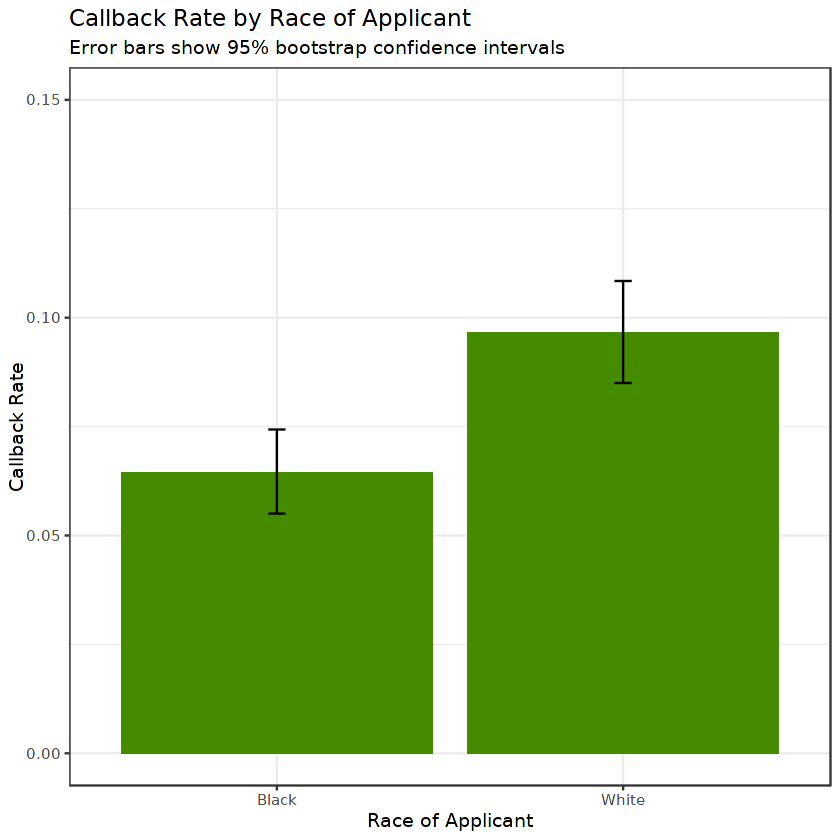

In [16]:
# Bar chart with error bars showing 95% CIs
# The error bars show the range of plausible values for each group's true callback rate
ggplot(plot_data, aes(y = meanCalls, x = race, ymin = lower95, ymax = upper95)) +
  geom_col(fill = "chartreuse4") +
  geom_errorbar(width = 0.05) +
  ylim(0, 0.15) +
  labs(
    title = "Callback Rate by Race of Applicant",
    subtitle = "Error bars show 95% bootstrap confidence intervals",
    x = "Race of Applicant",
    y = "Callback Rate"
  ) +
  theme_bw()

**What to look for in this plot:**
- The bars show the observed callback rate for each group
- The error bars show the 95% CI — the range of plausible true values
- If the confidence intervals **do not overlap**, that is informal evidence of a real difference
- Do the CIs overlap here? What does that suggest?

## Step 3: Understand the Permutation Logic

Here is a small example to build intuition for what permutation testing does.

**Original data** — race is associated with the applicant:

| Applicant | Race  | Callback |
|-----------|-------|----------|
| A         | Black | Yes      |
| B         | Black | No       |
| C         | Black | No       |
| D         | White | Yes      |
| E         | White | No       |
| F         | White | No       |

**After shuffling race labels** — the callback outcomes stay the same, but race is randomly reassigned:

| Applicant | Race (Shuffled) | Callback |
|-----------|-----------------|----------|
| A         | White           | Yes      |
| B         | Black           | No       |
| C         | White           | No       |
| D         | White           | Yes      |
| E         | Black           | No       |
| F         | Black           | No       |

After shuffling, we recalculate the difference in callback rates between "White" and "Black" groups. Because the race labels are now random, any difference we see is **purely due to chance**.

Repeat this 5,000 times → we get a distribution of differences that could occur **by chance alone** (the null distribution).

Then we ask: **how often does random shuffling produce a difference as large as the one we actually observed?** That proportion is the p-value.

## Step 4: Simulate the Null Distribution

Now let's do this formally using `infer`.

The key difference from the single-proportion test:
- `specify()` now takes **both** a `response` and an `explanatory` variable
- `hypothesize(null = "independence")` — the null is that the two variables are independent (unrelated)
- `generate(type = "permute")` — shuffles the explanatory variable instead of drawing from a distribution
- `calculate(stat = "diff in means")` — computes the difference in means between the two groups

In [17]:
# Simulate the null distribution using permutation
# infer will shuffle the race variable 5000 times and compute the
# difference in mean callback rates (White - Black) each time
null_dist <- resume_data |>
  specify(response = received_callback, explanatory = race) |>
  hypothesize(null = "independence") |>
  generate(reps = 5000, type = "permute") |>
  calculate(stat = "diff in means",
            order = c("white", "black"))  # White minus Black

# Each row is one permutation — the stat column is the difference in means
# for that shuffled dataset
head(null_dist)

replicate,stat
<int>,<dbl>
1,0.0032854209
2,0.0049281314
3,-0.0032854209
4,-0.0188911704
5,-0.0008213552
6,-0.0057494867


## Step 5: Calculate the p-value

The p-value is the proportion of permuted differences that are **as large or larger** than what we observed.

We use `direction = "greater"` because our alternative hypothesis is that white applicants have a *higher* callback rate than black applicants — a one-sided (upper-tail) test.

In [18]:
# Get the p-value
# direction = "greater" because H_A: callback rate for white > callback rate for black
p_val <- get_p_value(null_dist, obs_stat = teffect, direction = "greater")
p_val

Warning message:
“Please be cautious in reporting a p-value of 0. This result is an approximation
based on the number of `reps` chosen in the `generate()` step.
ℹ See `get_p_value()` (`?infer::get_p_value()`) for more information.”


p_value
<dbl>
0


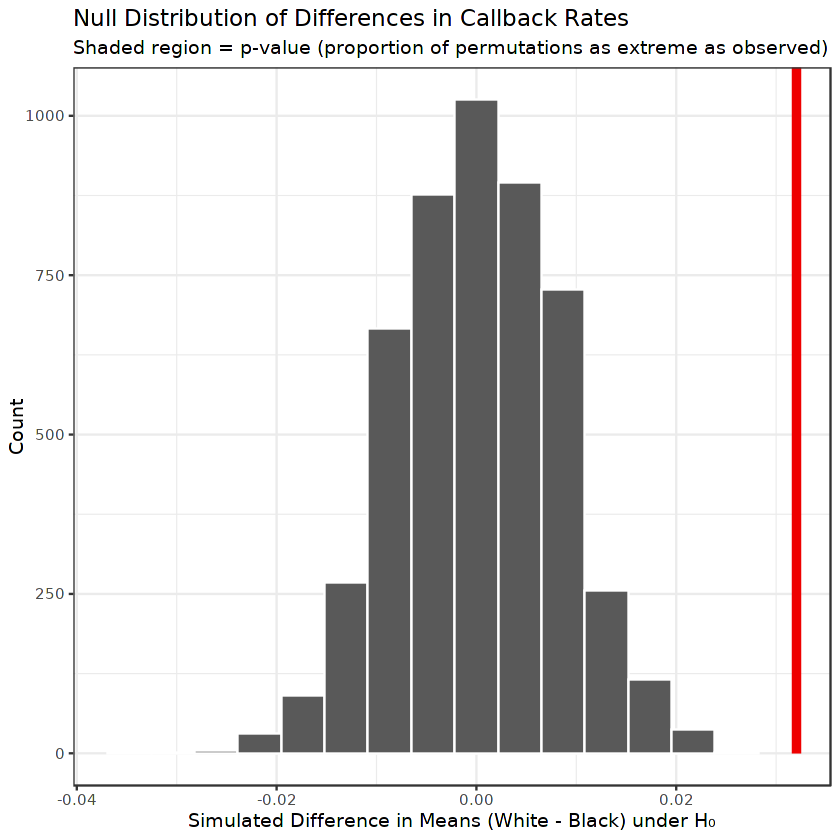

In [19]:
# Visualize the null distribution with the observed effect marked
# The shaded region is the p-value: how often does chance produce a gap this large?
visualize(null_dist) +
  shade_p_value(obs_stat = teffect, direction = "greater") +
  labs(
    title = "Null Distribution of Differences in Callback Rates",
    subtitle = "Shaded region = p-value (proportion of permutations as extreme as observed)",
    x = "Simulated Difference in Means (White - Black) under H₀",
    y = "Count"
  ) +
  theme_bw()

## Conclusion

- The p-value is very small (well below 0.05)
- We **reject** the null hypothesis
- The racial gap in callback rates is extremely unlikely to have occurred by chance alone
- This is strong statistical evidence of racial discrimination in hiring

**Full write-up of the test:**

> $H_0$: There is no relationship between the race of the applicant and callback rates — any observed difference is due to chance.
>
> $H_A$: White applicants receive callbacks at a higher rate than Black applicants.
>
> We observed a difference of approximately 3.2 percentage points (White − Black). After 5,000 permutations, virtually none produced a difference this large by chance. The p-value is < 0.05, so we reject $H_0$. There is statistically significant evidence of racial discrimination in callback rates.

## Extension: What if we had used a two-sided test?

We used a **one-sided** test above because we had a directional hypothesis (white applicants get *more* callbacks).

If we had no prior expectation about direction, we would use `direction = "two-sided"` — this checks whether the gap is extreme in *either* direction.

In [20]:
# Two-sided version: is the callback gap different from zero in either direction?
p_val_two <- get_p_value(null_dist, obs_stat = teffect, direction = "two-sided")
p_val_two

# Note: the two-sided p-value is roughly twice the one-sided p-value
# Both are still far below 0.05 in this case

Warning message:
“Please be cautious in reporting a p-value of 0. This result is an approximation
based on the number of `reps` chosen in the `generate()` step.
ℹ See `get_p_value()` (`?infer::get_p_value()`) for more information.”


p_value
<dbl>
0


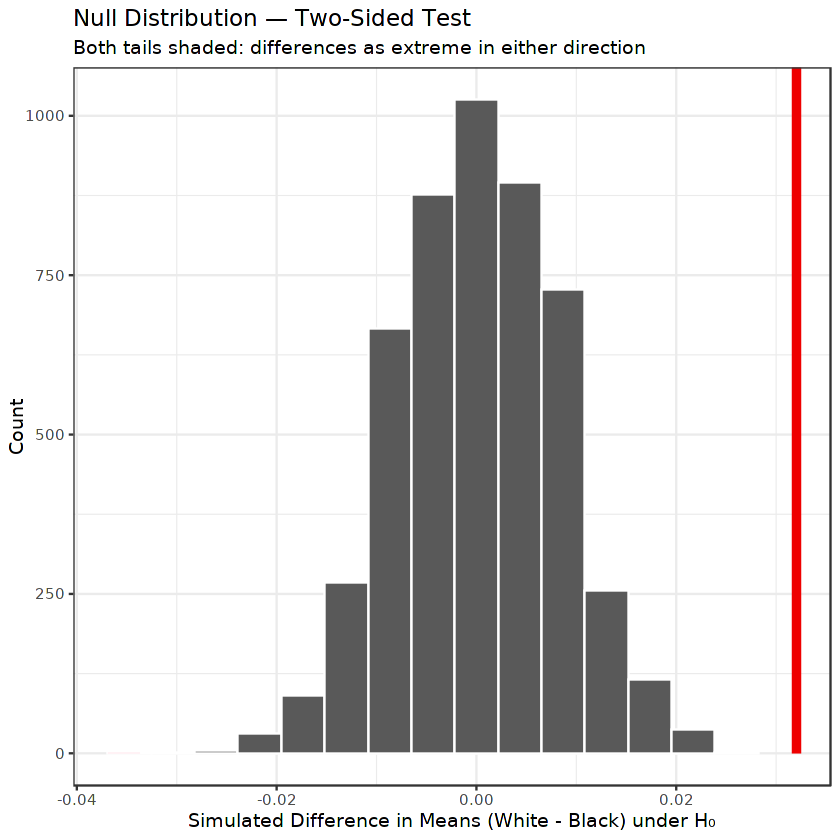

In [21]:
visualize(null_dist) +
  shade_p_value(obs_stat = teffect, direction = "two-sided") +
  labs(
    title = "Null Distribution — Two-Sided Test",
    subtitle = "Both tails shaded: differences as extreme in either direction",
    x = "Simulated Difference in Means (White - Black) under H₀",
    y = "Count"
  ) +
  theme_bw()

---
## Try It Out! Gender Discrimination

The `resume` dataset also contains a `gender` variable. Use the same workflow to test whether there is **gender discrimination** in callback rates.

Work through each step below.

### Step 1: Calculate the observed difference in callback rates by gender

In [ ]:
# YOUR CODE HERE
# Hint: same as the race analysis above, but group_by(gender) instead
# Save the mean for each group and compute the treatment effect (difference in means)

### Step 2: Bootstrap 95% CIs and plot

In [ ]:
# YOUR CODE HERE
# Hint: filter by gender ("male" and "female") and bootstrap each group separately
# Then build a plot_data tibble and use ggplot with geom_col() + geom_errorbar()

### Step 3: State your hypotheses

Write the null and alternative hypotheses in your own words:

- $H_0$: 
- $H_A$:

### Step 4: Simulate the null distribution and calculate the p-value

In [ ]:
# YOUR CODE HERE
# Hint: same pipeline as the race test, but explanatory = gender
# Think about: should this be a one-sided or two-sided test? Why?
# Use order = c("male", "female") to define the direction of the difference

### Step 5: Visualize the null distribution

In [ ]:
# YOUR CODE HERE
# visualize() + shade_p_value()

### Step 6: Conclusion

Based on your p-value, what do you conclude?

- Is there evidence of gender discrimination in callback rates?
- Would you reject or fail to reject $H_0$?
- How does the gender gap compare to the racial gap?